In [1]:
import torch

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

from PIL import ImageOps

import matplotlib.pyplot as plt

from torch import nn
from torchinfo import summary

from tqdm.auto import tqdm
from timeit import default_timer as timer

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

from sklearn.metrics import classification_report

from pathlib import Path


torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo configurado: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")



c:\env\gestos\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo configurado: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
train_directory = "dataset/divided/train/"
val_directory = "dataset/divided/val/"
test_directory = "dataset/divided/test/"


MODEL_PATH = Path(
    "model_trained"
)

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)


print("Carpeta de entrenamiento:", train_directory)
print("Carpeta de validacion:", val_directory)
print("Carpeta de prueba:", test_directory)

Carpeta de entrenamiento: dataset/divided/train/
Carpeta de validacion: dataset/divided/val/
Carpeta de prueba: dataset/divided/test/


In [3]:
transform_train = transforms.Compose([
    # Corrige la orientacion EXIF de fotos tomadas con celular
    transforms.Lambda(
        lambda image: ImageOps.exif_transpose(image)
    ),
    transforms.Grayscale(
        num_output_channels=1
    ),
    transforms.Resize(
        (224, 224)
    ),
    # Data augmentation enriquecida
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomRotation(
        degrees=12
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    # Normalizacion estandar para imagenes en escala de grises
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])


transform_test = transforms.Compose([
    transforms.Lambda(
        lambda image: ImageOps.exif_transpose(image)
    ),
    transforms.Grayscale(
        num_output_channels=1
    ),
    transforms.Resize(
        (224, 224)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])


In [4]:
train_dataset = ImageFolder(
    root=train_directory,
    transform=transform_train
)


val_dataset = ImageFolder(
    root=val_directory,
    transform=transform_test
)


test_dataset = ImageFolder(
    root=test_directory,
    transform=transform_test
)

In [5]:
print("Clases detectadas:")
print(train_dataset.classes)

print("\nIndices asignados:")
print(train_dataset.class_to_idx)

print("\nCantidad de imagenes:")
print("Entrenamiento:", len(train_dataset))
print("Validacion:", len(val_dataset))
print("Prueba:", len(test_dataset))

Clases detectadas:
['enojado', 'feliz', 'normal', 'triste']

Indices asignados:
{'enojado': 0, 'feliz': 1, 'normal': 2, 'triste': 3}

Cantidad de imagenes:
Entrenamiento: 941
Validacion: 158
Prueba: 158


In [6]:
assert train_dataset.classes == val_dataset.classes
assert train_dataset.classes == test_dataset.classes

print("Las clases coinciden en train, val y test.")

Las clases coinciden en train, val y test.


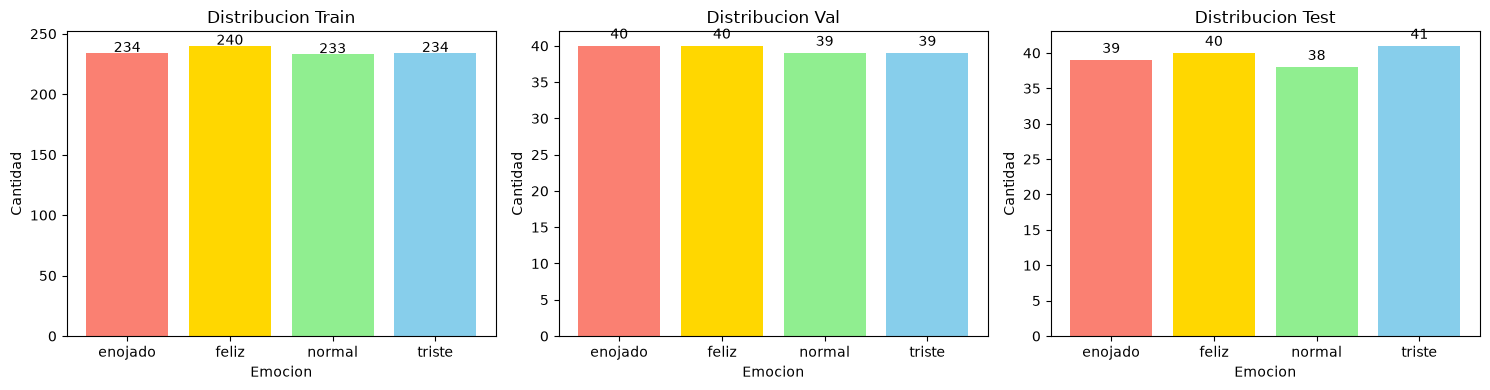

In [7]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, dataset, title in zip(
    axes,
    [train_dataset, val_dataset, test_dataset],
    ["Train", "Val", "Test"]
):
    counts = Counter(dataset.targets)
    class_names = [dataset.classes[i] for i in sorted(counts.keys())]
    values = [counts[i] for i in sorted(counts.keys())]

    ax.bar(
        class_names,
        values,
        color=["salmon", "gold", "lightgreen", "skyblue"]
    )

    ax.set_title(f"Distribucion {title}")
    ax.set_xlabel("Emocion")
    ax.set_ylabel("Cantidad")

    for i, v in enumerate(values):
        ax.text(i, v + 1, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

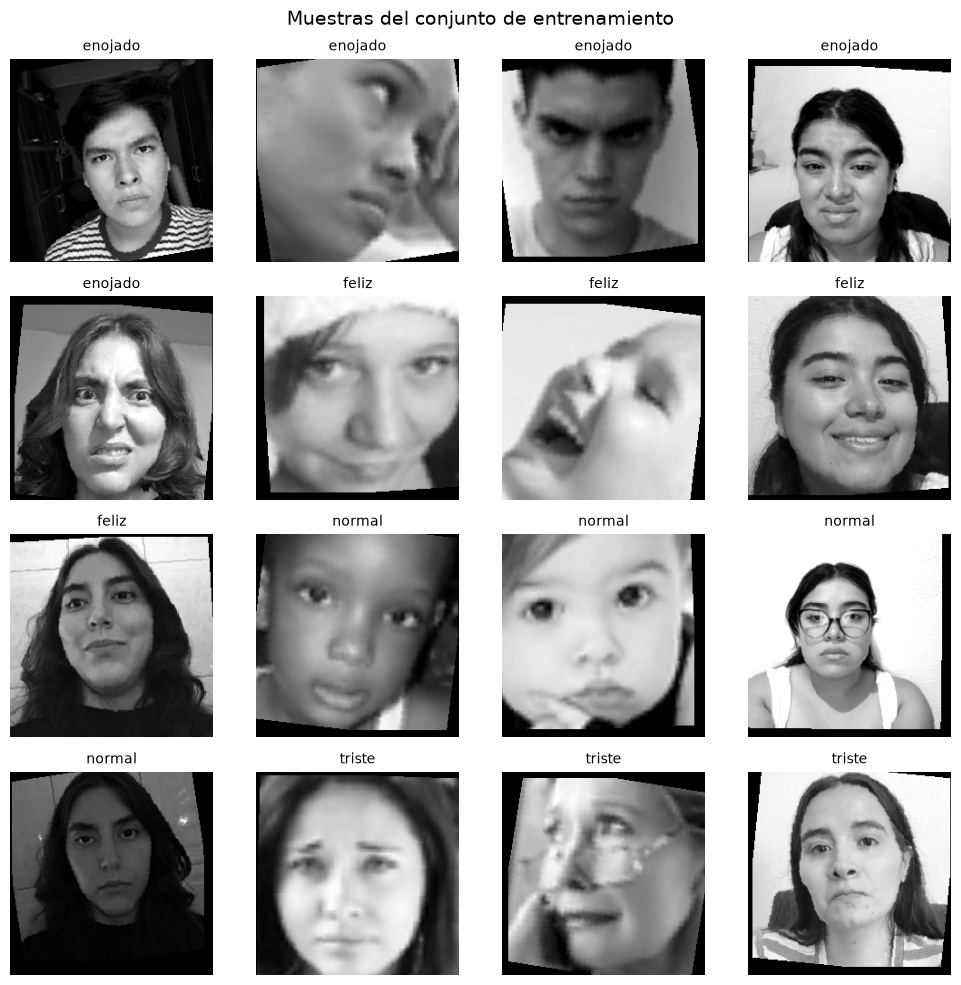

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
class_names = train_dataset.classes

for i, ax in enumerate(axes.flatten()):
    idx = i * (len(train_dataset) // 16)
    image, label = train_dataset[idx]

    image_display = image * 0.5 + 0.5
    image_display = image_display.squeeze()

    ax.imshow(image_display, cmap="gray")
    ax.set_title(class_names[label], fontsize=10)
    ax.axis("off")

plt.suptitle("Muestras del conjunto de entrenamiento", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
BATCH_SIZE = 32

# Usamos num_workers=0 para maxima compatibilidad en Windows Jupyter Notebook
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"Lotes en entrenamiento: {len(train_dataloader)}")
print(f"Lotes en validacion: {len(val_dataloader)}")
print(f"Lotes en prueba: {len(test_dataloader)}")

image_batch, label_batch = next(iter(train_dataloader))
print(f"Forma del lote de imagenes: {image_batch.shape}")
print(f"Forma del lote de etiquetas: {label_batch.shape}")


Lotes en entrenamiento: 30
Lotes en validacion: 5
Lotes en prueba: 5
Forma del lote de imagenes: torch.Size([32, 1, 224, 224])
Forma del lote de etiquetas: torch.Size([32])


In [10]:
class TinyVGG(nn.Module):
    """
    Red neuronal convolucional TinyVGG con arquitectura
    de tamano creciente progresivamente.
    Filtros: 16 -> 32 -> 64 (crecimiento progresivo).
    Entrena con algoritmo Adam (requisito del proyecto).
    """

    def __init__(
        self,
        input_shape: int,
        hidden_units: int,
        output_shape: int
    ):
        super().__init__()

        # Bloque convolucional 1: input_shape -> hidden_units (16)
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # Bloque convolucional 2: hidden_units -> hidden_units*2 (32)
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units * 2,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 2,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # Bloque convolucional 3: hidden_units*2 -> hidden_units*4 (64)
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 4,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(hidden_units * 4),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 4,
                out_channels=hidden_units * 4,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(hidden_units * 4),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # Clasificador con AdaptiveAvgPool2d y capas densas progresivas
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(
                in_features=hidden_units * 4 * 4 * 4,
                out_features=hidden_units * 8
            ),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(
                in_features=hidden_units * 8,
                out_features=output_shape
            )
        )

    def forward(
        self,
        x: torch.Tensor
    ) -> torch.Tensor:

        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.classifier(x)

        return x

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando dispositivo: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [12]:
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


NUM_EPOCHS = 60

# hidden_units=16: filtros 16 -> 32 -> 64 (crecimiento progresivo)
model_0 = TinyVGG(
    input_shape=1,
    hidden_units=16,
    output_shape=len(
        train_dataset.classes
    )
).to(device)


# CrossEntropyLoss con Label Smoothing para mejorar generalizacion en emociones sutiles
loss_fn = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


# Adam como optimizador (requisito del proyecto)
optimizer = torch.optim.Adam(
    params=model_0.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# Scheduler para reducir learning rate si el val_loss se desacelera
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4,
    min_lr=1e-6
)


print(model_0)


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fal

In [13]:
summary(
    model_0,
    input_size=(
        1,
        1,
        224,
        224
    )
)

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 4]                    --
├─Sequential: 1-1                        [1, 16, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 16, 224, 224]         160
│    └─BatchNorm2d: 2-2                  [1, 16, 224, 224]         32
│    └─ReLU: 2-3                         [1, 16, 224, 224]         --
│    └─Conv2d: 2-4                       [1, 16, 224, 224]         2,320
│    └─BatchNorm2d: 2-5                  [1, 16, 224, 224]         32
│    └─ReLU: 2-6                         [1, 16, 224, 224]         --
│    └─MaxPool2d: 2-7                    [1, 16, 112, 112]         --
├─Sequential: 1-2                        [1, 32, 56, 56]           --
│    └─Conv2d: 2-8                       [1, 32, 112, 112]         4,640
│    └─BatchNorm2d: 2-9                  [1, 32, 112, 112]         64
│    └─ReLU: 2-10                        [1, 32, 112, 112]         --
│    └─C

In [14]:
model_output = model_0(
    image_batch.to(
        device
    )
)


print("Forma de la salida:")
print(model_output.shape)

print("\nPrimera salida (logits):")
print(model_output[0])

Forma de la salida:
torch.Size([32, 4])

Primera salida (logits):
tensor([-0.1794, -0.1971, -0.0859,  0.3808], device='cuda:0',
       grad_fn=<SelectBackward0>)


In [15]:
def train_step(
    model,
    dataloader,
    loss_fn,
    optimizer,
    device=device
):

    model.train()

    train_loss = 0
    train_acc = 0

    for batch, (X, y) in enumerate(dataloader):

        X = X.to(device)
        y = y.to(device)

        # Prediccion
        y_pred = model(X)

        # Calcular perdida
        loss = loss_fn(
            y_pred,
            y
        )

        train_loss += loss.item()

        # Limpiar gradientes anteriores
        optimizer.zero_grad()

        # Retropropagacion
        loss.backward()

        # Actualizar los pesos
        optimizer.step()

        # Obtener la clase predicha
        y_pred_class = torch.argmax(
            y_pred,
            dim=1
        )

        # Calcular accuracy del lote
        train_acc += (
            (y_pred_class == y)
            .sum()
            .item()
            / len(y_pred)
        )

    # Promedio de todos los lotes
    train_loss = (
        train_loss
        / len(dataloader)
    )

    train_acc = (
        train_acc
        / len(dataloader)
    )

    return (
        train_loss,
        train_acc
    )

In [16]:
def val_step(
    model,
    dataloader,
    loss_fn,
    optimizer,
    device=device
):

    model.eval()

    val_loss = 0
    val_acc = 0

    with torch.inference_mode():

        for batch, (X, y) in enumerate(dataloader):

            X = X.to(device)
            y = y.to(device)

            val_pred_logits = model(X)

            loss = loss_fn(
                val_pred_logits,
                y
            )

            val_loss += loss.item()

            y_pred_class = torch.argmax(
                val_pred_logits,
                dim=1
            )

            val_acc += (
                (y_pred_class == y)
                .sum()
                .item()
                / len(val_pred_logits)
            )

    val_loss = (
        val_loss
        / len(dataloader)
    )

    val_acc = (
        val_acc
        / len(dataloader)
    )

    return (
        val_loss,
        val_acc
    )

In [17]:
def train(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    loss_fn,
    epochs,
    patience=12,
    min_delta=0.001,
    min_epochs=15,
    scheduler=None,
    device=device
):

    results = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float("inf")

    # Cuenta cuantas epocas consecutivas no presentan mejora
    epochs_without_improvement = 0

    MODEL_NAME = "EnojadoFelizNormalTriste.pth"
    MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

    for epoch in tqdm(range(epochs)):

        # Entrenamiento
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )

        # Validacion
        val_loss, val_acc = val_step(
            model=model,
            dataloader=val_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )

        # Actualizar scheduler con val_loss si esta presente
        if scheduler is not None:
            scheduler.step(val_loss)

        # Se considera mejora cuando val_loss disminuye al menos min_delta
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                MODEL_SAVE_PATH
            )
            improvement_message = "Mejor modelo guardado"
        else:
            epochs_without_improvement += 1
            improvement_message = (
                f"Sin mejora: "
                f"{epochs_without_improvement}/{patience}"
            )

        print(
            f"Epoch: {epoch + 1}/{epochs} | "
            f"Train loss: {train_loss:.4f} "
            f"Train acc: {train_acc:.4f} | "
            f"Val loss: {val_loss:.4f} "
            f"Val acc: {val_acc:.4f} | "
            f"{improvement_message}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

        # Criterio de parada temprana (Early Stopping)
        if (
            epoch + 1 >= min_epochs
            and epochs_without_improvement >= patience
        ):
            print("\n[Early Stopping] Entrenamiento detenido anticipadamente.")
            print(f"Se completaron al menos {min_epochs} epocas.")
            print(f"Sin mejora en val_loss durante {patience} epocas consecutivas.")
            break

    return results


In [18]:
start_time = timer()

model_0_results = train(
    model=model_0,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    patience=12,
    min_delta=0.001,
    min_epochs=15,
    scheduler=scheduler,
    device=device
)

end_time = timer()

print(
    f"Tiempo de entrenamiento: "
    f"{end_time - start_time:.3f} "
    f"segundos"
)


  2%|▏         | 1/60 [00:59<58:41, 59.68s/it]

Epoch: 1/60 | Train loss: 1.4265 Train acc: 0.2337 | Val loss: 1.3904 Val acc: 0.2500 | Mejor modelo guardado


  3%|▎         | 2/60 [01:59<57:47, 59.78s/it]

Epoch: 2/60 | Train loss: 1.3916 Train acc: 0.2296 | Val loss: 1.3839 Val acc: 0.2379 | Mejor modelo guardado


  5%|▌         | 3/60 [03:30<1:10:07, 73.82s/it]

...

Epoch: 58/60 | Train loss: 1.1663 Train acc: 0.5163 | Val loss: 1.0914 Val acc: 0.5600 | Sin mejora: 4/12


 98%|█████████▊| 59/60 [1:52:55<01:11, 71.52s/it]

Epoch: 59/60 | Train loss: 1.1476 Train acc: 0.5097 | Val loss: 1.0481 Val acc: 0.5842 | Mejor modelo guardado


100%|██████████| 60/60 [1:53:53<00:00, 113.89s/it]

Epoch: 60/60 | Train loss: 1.1414 Train acc: 0.5399 | Val loss: 1.0559 Val acc: 0.6067 | Sin mejora: 1/12
Tiempo de entrenamiento: 6833.676 segundos


In [19]:
def plot_loss_curves(results):

    train_loss = results["train_loss"]
    val_loss = results["val_loss"]
    train_acc = results["train_acc"]
    val_acc = results["val_acc"]

    epochs = range(len(train_loss))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, val_acc, label="val_acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    plt.show()

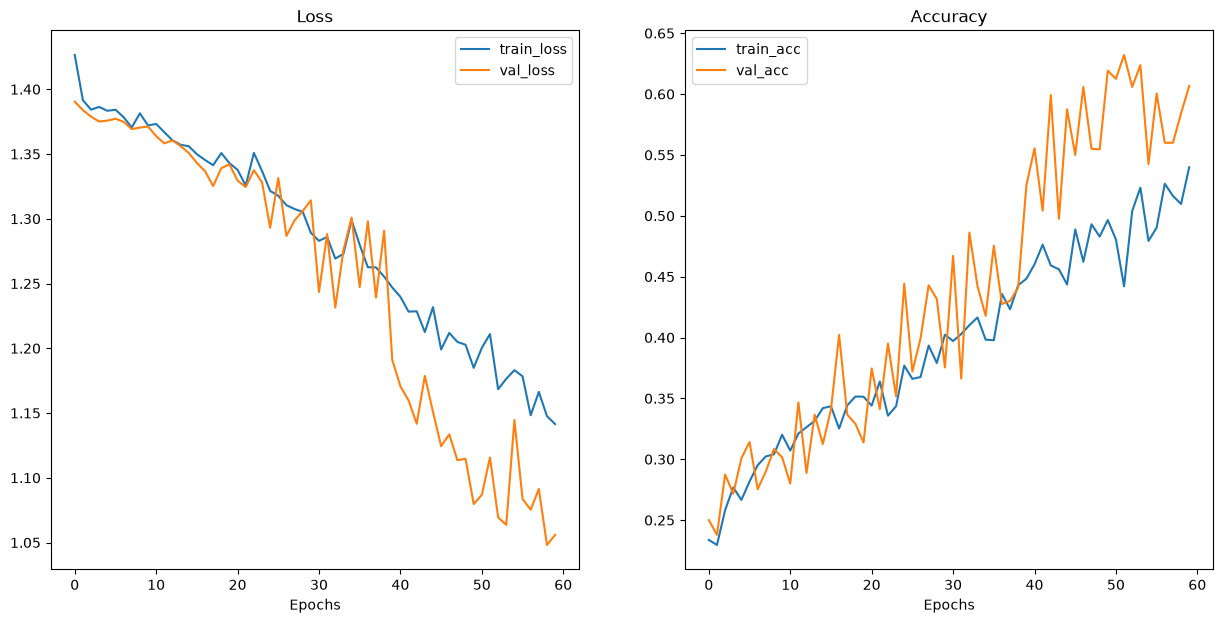

In [20]:
plot_loss_curves(
    model_0_results
)

In [21]:
model_0.load_state_dict(
    torch.load(
        MODEL_PATH / "EnojadoFelizNormalTriste.pth",
        map_location=device
    )
)

print("Mejor modelo cargado correctamente.")

Mejor modelo cargado correctamente.


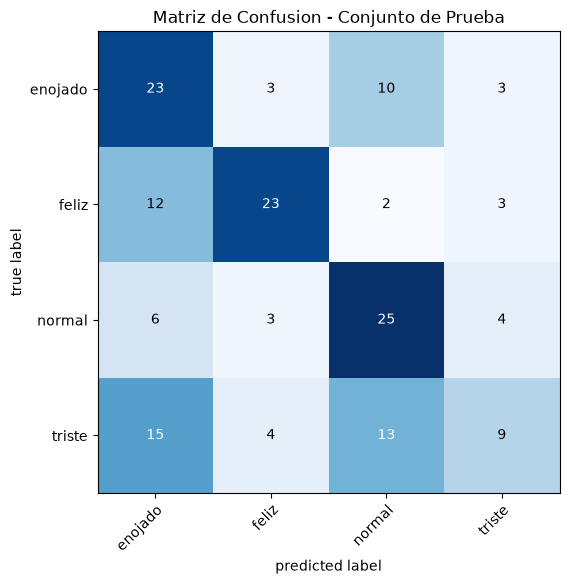

In [22]:
model_0.eval()

all_preds = []
all_labels = []

with torch.inference_mode():

    for X, y in test_dataloader:

        X = X.to(device)
        y = y.to(device)

        logits = model_0(X)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())


all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)


confmat = ConfusionMatrix(
    task="multiclass",
    num_classes=len(train_dataset.classes)
)

confmat_tensor = confmat(
    preds=all_preds,
    target=all_labels
)


fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=train_dataset.classes,
    figsize=(8, 6)
)

plt.title("Matriz de Confusion - Conjunto de Prueba")
plt.show()

In [23]:
report = classification_report(
    y_true=all_labels.numpy(),
    y_pred=all_preds.numpy(),
    target_names=train_dataset.classes,
    digits=4
)

print("=" * 60)
print("REPORTE DE CLASIFICACION - CONJUNTO DE PRUEBA")
print("=" * 60)
print(report)

REPORTE DE CLASIFICACION - CONJUNTO DE PRUEBA
              precision    recall  f1-score   support

     enojado     0.4107    0.5897    0.4842        39
       feliz     0.6970    0.5750    0.6301        40
      normal     0.5000    0.6579    0.5682        38
      triste     0.4737    0.2195    0.3000        41

    accuracy                         0.5063       158
   macro avg     0.5203    0.5105    0.4956       158
weighted avg     0.5210    0.5063    0.4935       158



In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_true = all_labels.numpy()
y_pred_arr = all_preds.numpy()

accuracy = accuracy_score(y_true, y_pred_arr)
precision = precision_score(y_true, y_pred_arr, average="weighted")
recall = recall_score(y_true, y_pred_arr, average="weighted")
f1 = f1_score(y_true, y_pred_arr, average="weighted")

print("=" * 40)
print("METRICAS GLOBALES (weighted)")
print("=" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

METRICAS GLOBALES (weighted)
Accuracy  : 0.5063
Precision : 0.5210
Recall    : 0.5063
F1-Score  : 0.4935


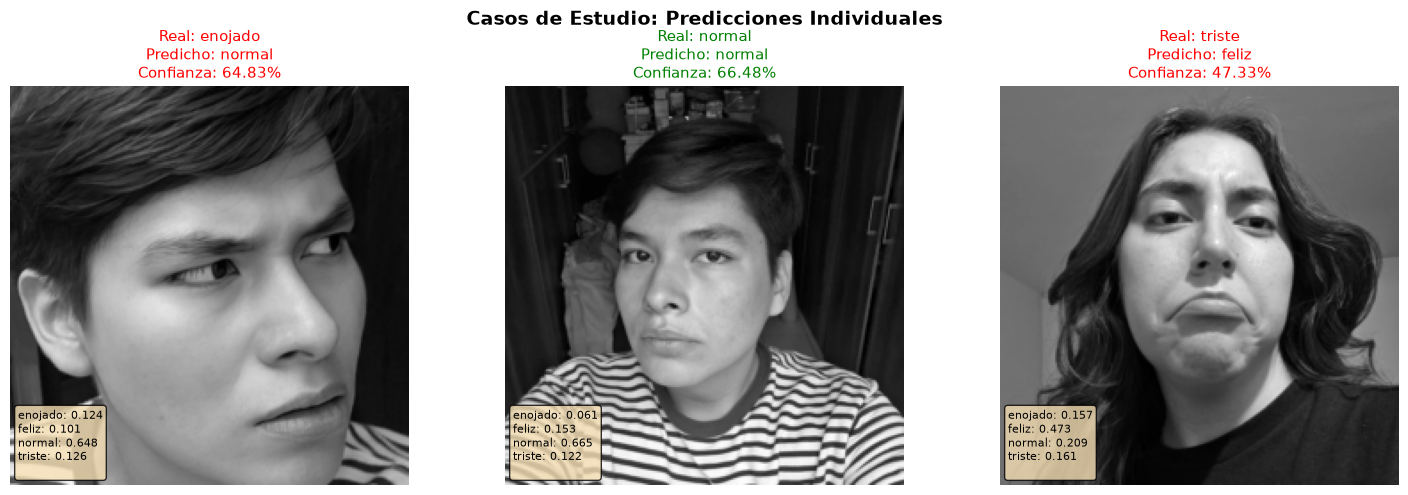

In [25]:
import torch.nn.functional as F

model_0.eval()

sample_indices = [0, len(test_dataset) // 2, len(test_dataset) - 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(sample_indices):

    image, true_label = test_dataset[idx]

    image_tensor = image.unsqueeze(0).to(device)

    with torch.inference_mode():
        logits = model_0(image_tensor)
        probabilities = F.softmax(logits, dim=1)

    pred_label = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][pred_label].item()

    img_display = image * 0.5 + 0.5
    img_display = img_display.squeeze().numpy()

    axes[i].imshow(img_display, cmap='gray')

    color = 'green' if pred_label == true_label else 'red'

    real_name = train_dataset.classes[true_label]
    pred_name = train_dataset.classes[pred_label]
    axes[i].set_title(
        f'Real: {real_name}\nPredicho: {pred_name}\nConfianza: {confidence:.2%}',
        color=color,
        fontsize=11
    )

    axes[i].axis('off')

    probs_text = ''
    for j, cls in enumerate(train_dataset.classes):
        p = probabilities[0][j].item()
        probs_text += f'{cls}: {p:.3f}\n'

    axes[i].text(
        0.02, 0.02, probs_text,
        transform=axes[i].transAxes,
        fontsize=8,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )


plt.suptitle(
    'Casos de Estudio: Predicciones Individuales',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

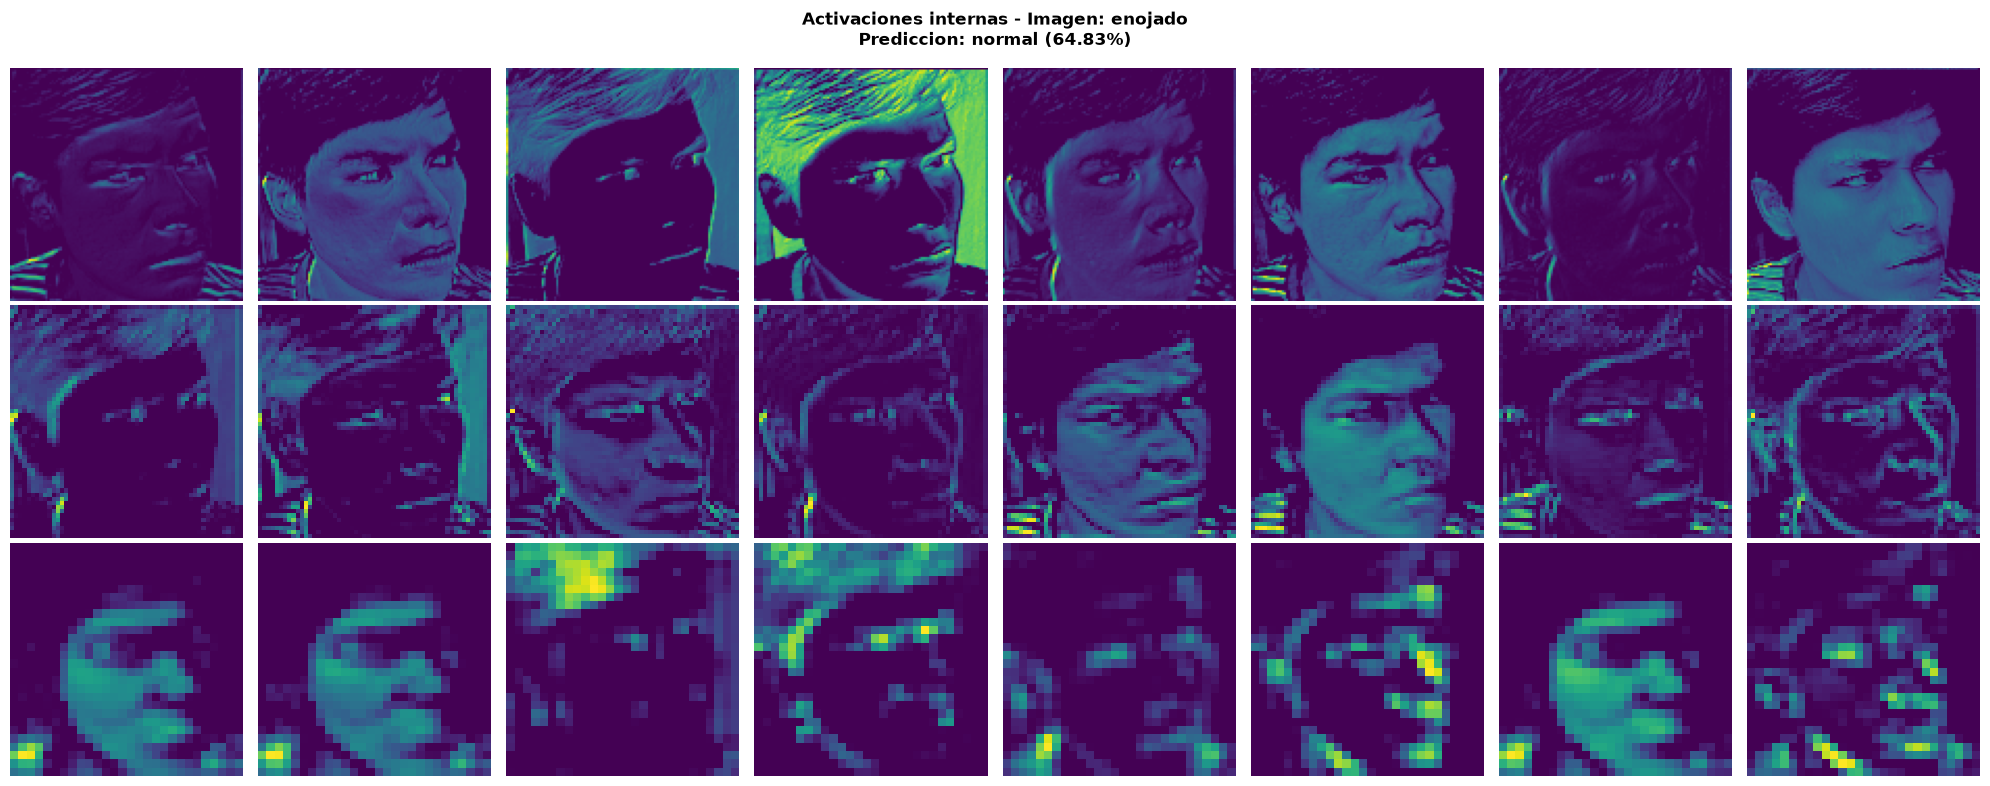

In [26]:
sample_image, sample_label = test_dataset[0]
sample_tensor = sample_image.unsqueeze(0).to(device)

activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

hook1 = model_0.conv_block_1.register_forward_hook(get_activation('conv_block_1'))
hook2 = model_0.conv_block_2.register_forward_hook(get_activation('conv_block_2'))
hook3 = model_0.conv_block_3.register_forward_hook(get_activation('conv_block_3'))

with torch.inference_mode():
    output = model_0(sample_tensor)
    probs = F.softmax(output, dim=1)

hook1.remove()
hook2.remove()
hook3.remove()

fig, axes = plt.subplots(3, 8, figsize=(20, 8))

for block_idx, (block_name, act) in enumerate(activations.items()):
    act_np = act.squeeze(0).cpu().numpy()
    n_filters = min(8, act_np.shape[0])

    for f_idx in range(n_filters):
        axes[block_idx, f_idx].imshow(
            act_np[f_idx],
            cmap='viridis'
        )
        axes[block_idx, f_idx].axis('off')

    axes[block_idx, 0].set_ylabel(
        block_name.replace('_', ' ').title(),
        fontsize=10
    )


pred_class = train_dataset.classes[probs.argmax().item()]
pred_conf = probs.max().item()
real_class = train_dataset.classes[sample_label]
plt.suptitle(
    f'Activaciones internas - Imagen: {real_class}\n'
    f'Prediccion: {pred_class} ({pred_conf:.2%})',
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

## Evaluacion en Tiempo Real con Camara Web (OpenCV)
Permite evaluar el modelo `model_0` en tiempo real utilizando la camara web y deteccion facial con Haar Cascades.
- Presiona la tecla **`q`** en la ventana de video para finalizar la captura.

In [27]:
import cv2
import torch
from torchvision import transforms

# 1. Cargar el detector de rostros de Haar Cascades
cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_detector = cv2.CascadeClassifier(cascade_path)

if face_detector.empty():
    face_detector = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

# 2. Inicializar la camara web
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
if not cap.isOpened():
    cap = cv2.VideoCapture(0)

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

# 3. Transformaciones para adaptar el fotograma al modelo TinyVGG (1 canal, 224x224, normalizado)
webcam_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

frame_counter = 0
last_label = "Esperando rostro"
last_confidence = 0.0

# Poner el modelo en modo de evaluacion
model_0.eval()

if not cap.isOpened():
    print("Error: no se pudo abrir la camara web.")
else:
    print("Camara iniciada correctamente.")
    print("Presiona la tecla 'q' en la ventana de video para salir.")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Error: no se pudo obtener el fotograma.")
            break

        # Convertir a escala de grises para el detector de rostros
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_detector.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(120, 120)
        )

        if len(faces) > 0:
            # Seleccionar el rostro mas grande en el encuadre
            x, y, w, h = max(
                faces,
                key=lambda face: (face[2] * face[3])
            )

            # Margen del 15% para capturar el rostro completo
            margin_x = int(w * 0.15)
            margin_y = int(h * 0.15)

            x1 = max(0, x - margin_x)
            y1 = max(0, y - margin_y)
            x2 = min(gray.shape[1], x + w + margin_x)
            y2 = min(gray.shape[0], y + h + margin_y)

            face_gray = gray[y1:y2, x1:x2]

            frame_counter += 1

            # Inferencia cada 5 fotogramas para mantener fluidez
            if frame_counter % 5 == 0 and face_gray.size > 0:
                tensor = (
                    webcam_transform(face_gray)
                    .unsqueeze(0)
                    .to(device)
                )

                with torch.inference_mode():
                    pred_logits = model_0(tensor)
                    probabilities = torch.softmax(pred_logits, dim=1)
                    confidence, pred_class = torch.max(probabilities, dim=1)

                last_label = train_dataset.classes[pred_class.item()]
                last_confidence = confidence.item() * 100

            # Dibujar rectangulo sobre el rostro
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            text = f"{last_label}: {last_confidence:.1f}%"

            cv2.putText(
                frame,
                text,
                (x1, max(30, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )

        else:
            cv2.putText(
                frame,
                "Rostro no detectado",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 0, 255),
                2
            )

        cv2.imshow("Reconocimiento de Emociones - Tiempo Real", frame)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Camara cerrada correctamente.")


Camara iniciada correctamente.
Presiona la tecla 'q' en la ventana de video para salir.
Camara cerrada correctamente.
